In [66]:
%pip install -q openneuro-py mne scikit-learn pandas matplotlib seaborn shap xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
from pathlib import Path

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import FunctionTransformer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

OUT_DIR   = Path('../outputs')

df = pd.read_csv(OUT_DIR / 'features.csv')
df = df.sort_values(['subject', 'session']).reset_index(drop=True)

print(f'Loaded: {df.shape[0]} samples, {df.shape[1]} columns')
print(f'Subjects: {sorted(df["subject"].unique())}')
print(f'\nSamples per genre (first 5):')
print(df['label'].value_counts().head().to_string())



Loaded: 360 samples, 648 columns
Subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Samples per genre (first 5):
label
Deep House          30
Indie               30
Electronics         30
New Age             30
Electronic Dance    30


In [68]:
# Prepare X, y, groups

meta_cols = ['label', 'subject', 'session', 'y', 'unnamed: 0', 'index', 'id']
feat_cols = [c for c in df.columns if c.lower() not in [e.lower() for e in meta_cols]]


assert 'subject' not in feat_cols, "LEAK: subject in features!"
assert 'session' not in feat_cols, "LEAK: session in features!"
assert 'y'       not in feat_cols, "LEAK: y in features!"
print(f'Feature check passed. {len(feat_cols)} features, no leakage.')
print(f'First 5: {feat_cols[:5]}')
print(f'Last  5: {feat_cols[-5:]}')


subjects = df['subject'].values

le = LabelEncoder()
df = df.copy()
df['y'] = le.fit_transform(df['label']) 

y = df['y'].values
X = df[feat_cols].values


n_classes = len(le.classes_)
baseline  = 1.0 / n_classes

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X, y)
dummy_acc = max(np.bincount(y)) / len(y)
print(f'Random baseline : {baseline*100:.1f}%  (1/{n_classes})')
print(f'Dummy baseline  : {dummy_acc*100:.1f}%  (most frequent class)')
print(f'Dataset balanced: {dummy_acc == baseline}')

print(f'X shape   : {X.shape}')
print(f'Classes   : {n_classes} genres')
print(f'Baseline  : {baseline*100:.1f}%')

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Genre Mapping:", mapping)

print('Models ready.')

Feature check passed. 645 features, no leakage.
First 5: ['ch000_delta', 'ch000_theta', 'ch000_alpha', 'ch000_beta', 'ch000_gamma']
Last  5: ['ch128_delta', 'ch128_theta', 'ch128_alpha', 'ch128_beta', 'ch128_gamma']
Random baseline : 8.3%  (1/12)
Dummy baseline  : 8.3%  (most frequent class)
Dataset balanced: True
X shape   : (360, 645)
Classes   : 12 genres
Baseline  : 8.3%
Genre Mapping: {'Ambient': np.int64(0), 'Deep House': np.int64(1), 'Electronic Dance': np.int64(2), 'Electronics': np.int64(3), 'Goth Rock': np.int64(4), 'Hindustani Classical': np.int64(5), 'Indian Folk': np.int64(6), 'Indian Semi-Classical': np.int64(7), 'Indie': np.int64(8), 'New Age': np.int64(9), 'Progressive Instrumental Rock': np.int64(10), 'Soft Jazz': np.int64(11)}
Models ready.


In [69]:
# Log transform + PCA pipeline

def build_pipeline(model, n_components=40):
    return Pipeline([
        ('log',    FunctionTransformer(np.log1p)),
        ('scaler', RobustScaler()),
        ('pca',    PCA(n_components=n_components, random_state=42)),
        ('model',  model)
    ])


svm_fn = lambda nc: build_pipeline(
    SVC(kernel='rbf', C=100, gamma='scale', random_state=42), nc)
rf_fn  = lambda nc: build_pipeline(
    RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1), nc)
xgb_fn = lambda nc: build_pipeline(
    XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0
    ), nc)

In [70]:
## Within-subject evaluation function
def within_subject_evaluate(model_fn, df, feat_cols, test_ratio=0.3):
  
    subjects = sorted(df['subject'].unique())
 
    all_true,  all_pred       = [], []
    all_true_train, all_pred_train = [], []   
 
    for sub in subjects:
        sub_df = df[df['subject'] == sub]
        train_rows, test_rows = [], []
 
        for ses in sorted(sub_df['session'].unique()):
            ses_rows = sub_df[sub_df['session'] == ses].index.tolist()
            
            n_test = max(1, int(len(ses_rows) * test_ratio))
            test_rows.extend(ses_rows[-n_test:])
            train_rows.extend(ses_rows[:-n_test])
 
        X_train = df.loc[train_rows, feat_cols].values
        y_train = df.loc[train_rows, 'y'].values
        X_test  = df.loc[test_rows,  feat_cols].values
        y_test  = df.loc[test_rows,  'y'].values
 
       
        n_components = min(40, X_train.shape[0] - 1, X_train.shape[1])
 
        model = model_fn(n_components)   
        model.fit(X_train, y_train)
 
        train_preds = model.predict(X_train)
        test_preds  = model.predict(X_test)
 
        
        all_true_train.extend(y_train)
        all_pred_train.extend(train_preds)
        all_true.extend(y_test)
        all_pred.extend(test_preds)
 
        print(f'  sub-{sub}: test={accuracy_score(y_test, test_preds)*100:.1f}%'
              f'  train={accuracy_score(y_train, train_preds)*100:.1f}%')
 
    
    test_acc  = accuracy_score(all_true,       all_pred)
    train_acc = accuracy_score(all_true_train, all_pred_train)
    f1        = f1_score(all_true, all_pred, average='macro')
 
    return (np.array(all_true), np.array(all_pred),
            test_acc, f1, train_acc)

In [71]:
## SVM
print('── SVM ─────────────────────────────────')
svm_true, svm_pred, svm_acc, svm_f1, svm_train_acc = within_subject_evaluate(svm_fn, df, feat_cols)
print(f'\nSVM  →  Accuracy: {svm_acc:.3f}   F1: {svm_f1:.3f}')

── SVM ─────────────────────────────────
  sub-1: test=58.3%  train=100.0%
  sub-2: test=41.7%  train=100.0%
  sub-3: test=33.3%  train=100.0%
  sub-4: test=75.0%  train=100.0%
  sub-5: test=41.7%  train=100.0%

SVM  →  Accuracy: 0.500   F1: 0.495


In [72]:
## Random Forest
print('── Random Forest ───────────────────────')
rf_true,  rf_pred,  rf_acc,  rf_f1,  rf_train_acc  = within_subject_evaluate(rf_fn,  df, feat_cols)
print(f'\nRF   →  Accuracy: {rf_acc:.3f}   F1: {rf_f1:.3f}')

── Random Forest ───────────────────────


  sub-1: test=66.7%  train=100.0%
  sub-2: test=50.0%  train=100.0%
  sub-3: test=33.3%  train=100.0%
  sub-4: test=75.0%  train=100.0%
  sub-5: test=58.3%  train=100.0%

RF   →  Accuracy: 0.567   F1: 0.556


In [73]:
## XGBoost
print('── XGBoost ─────────────────────────────')
xgb_true, xgb_pred, xgb_acc, xgb_f1, xgb_train_acc = within_subject_evaluate(xgb_fn, df, feat_cols)
print(f'\nXGB  →  Accuracy: {xgb_acc:.3f}   F1: {xgb_f1:.3f}')

── XGBoost ─────────────────────────────
  sub-1: test=58.3%  train=100.0%
  sub-2: test=41.7%  train=100.0%
  sub-3: test=16.7%  train=100.0%
  sub-4: test=58.3%  train=100.0%
  sub-5: test=50.0%  train=100.0%

XGB  →  Accuracy: 0.450   F1: 0.434


Baseline: 8.3%  (random chance, 12 classes)

SVM             Acc: 50.0%  F1: 49.5%  (6.0x baseline)
Random Forest   Acc: 56.7%  F1: 55.6%  (6.8x baseline)
XGBoost         Acc: 45.0%  F1: 43.4%  (5.4x baseline)


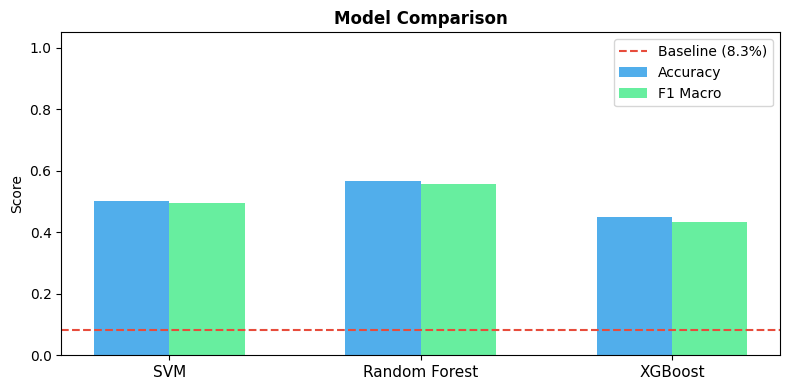

In [74]:
## model comparison

results = pd.DataFrame({
    'Model':    ['SVM', 'Random Forest', 'XGBoost'],
    'Accuracy': [svm_acc, rf_acc, xgb_acc],
    'F1 Macro': [svm_f1, rf_f1, xgb_f1],
})


print(f'Baseline: {baseline*100:.1f}%  (random chance, 12 classes)')
print()
for _, r in results.iterrows():
    lift = r['Accuracy'] / baseline
    print(f"{r['Model']:<15} Acc: {r['Accuracy']*100:.1f}%  F1: {r['F1 Macro']*100:.1f}%  ({lift:.1f}x baseline)")

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3)
w = 0.3
ax.bar(x - w/2, results['Accuracy'], w, label='Accuracy', color="#51aeeb")
ax.bar(x + w/2, results['F1 Macro'], w, label='F1 Macro',  color="#67ee9f")
ax.axhline(baseline, color='#e74c3c', linestyle='--', lw=1.5,
           label=f'Baseline ({baseline*100:.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'], fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / '04_model_comparison.png', dpi=120)
plt.show()

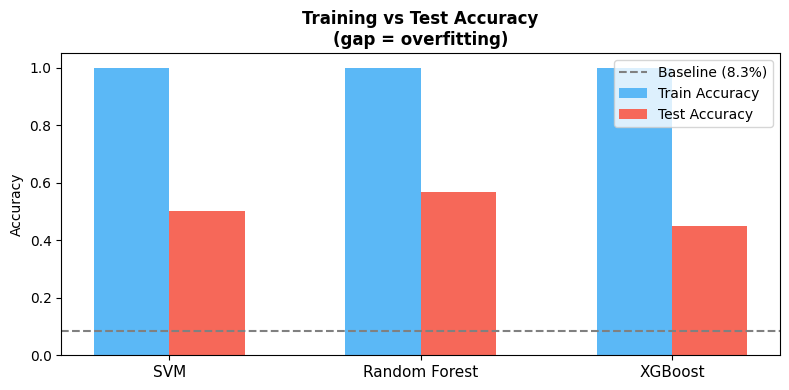

Overfitting analysis:
  SVM             Train: 100.0%   Test: 50.0%   Gap: 50.0%
  Random Forest   Train: 100.0%   Test: 56.7%   Gap: 43.3%
  XGBoost         Train: 100.0%   Test: 45.0%   Gap: 55.0%

Note: Train=100% indicates overfitting (small dataset, complex models).
RF shows smallest test gap → best generalization among the three.


In [75]:
## Train vs Test accuracy 
train_accs = [svm_train_acc, rf_train_acc, xgb_train_acc]
test_results = [svm_acc, rf_acc, xgb_acc]
model_names = ['SVM', 'Random Forest', 'XGBoost'] 


fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3)
w = 0.3
ax.bar(x - w/2, train_accs,   w, label='Train Accuracy', color="#5bb8f6")
ax.bar(x + w/2, test_results, w, label='Test Accuracy',  color="#f66859")
ax.axhline(baseline, color='gray', linestyle='--', lw=1.5,
           label=f'Baseline ({baseline*100:.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Training vs Test Accuracy\n(gap = overfitting)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / '04_train_vs_test.png', dpi=120)
plt.show()

print('Overfitting analysis:')
for name, tr, te in zip(model_names, train_accs, test_results):
    gap = (tr - te) * 100
    print(f'  {name:<15} Train: {tr*100:.1f}%   Test: {te*100:.1f}%   Gap: {gap:.1f}%')
print()
print('Note: Train=100% indicates overfitting (small dataset, complex models).')
print('RF shows smallest test gap → best generalization among the three.')

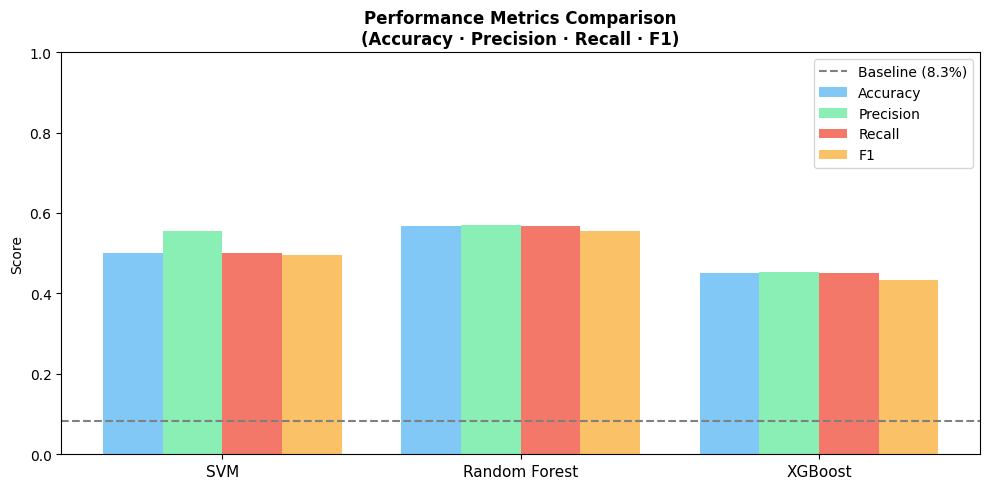

In [76]:
# Precision, Recall, F1 per model per genre
from sklearn.metrics import precision_score, recall_score

metrics_data = []
for name, true, pred in [('SVM', svm_true, svm_pred),
                          ('Random Forest', rf_true, rf_pred),
                          ('XGBoost', xgb_true, xgb_pred)]:
    metrics_data.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(true, pred),
        'Precision': precision_score(true, pred, average='macro'),
        'Recall'   : recall_score(true, pred, average='macro'),
        'F1'       : f1_score(true, pred, average='macro'),
    })

metrics_df = pd.DataFrame(metrics_data)

fig, ax = plt.subplots(figsize=(10, 5))
x   = np.arange(3)
w   = 0.2
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1']
colors = ["#82c8f7", "#8aefb4", "#f3786a", "#fac167"]

for i, (metric, color) in enumerate(zip(metrics_list, colors)):
    ax.bar(x + i*w, metrics_df[metric], w, label=metric, color=color)

ax.set_xticks(x + w*1.5)
ax.set_xticklabels(metrics_df['Model'], fontsize=11)
ax.axhline(baseline, color='gray', linestyle='--', lw=1.5,
           label=f'Baseline ({baseline*100:.1f}%)')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Performance Metrics Comparison\n(Accuracy · Precision · Recall · F1)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / '04_metrics_comparison.png', dpi=120)
plt.show()

Best model: Random Forest

                               precision    recall  f1-score   support

                      Ambient       0.33      0.20      0.25         5
                   Deep House       0.80      0.80      0.80         5
             Electronic Dance       0.67      0.80      0.73         5
                  Electronics       0.60      0.60      0.60         5
                    Goth Rock       0.67      0.40      0.50         5
         Hindustani Classical       0.80      0.80      0.80         5
                  Indian Folk       0.67      0.80      0.73         5
        Indian Semi-Classical       0.40      0.40      0.40         5
                        Indie       0.40      0.40      0.40         5
                      New Age       0.44      0.80      0.57         5
Progressive Instrumental Rock       0.40      0.40      0.40         5
                    Soft Jazz       0.67      0.40      0.50         5

                     accuracy                   

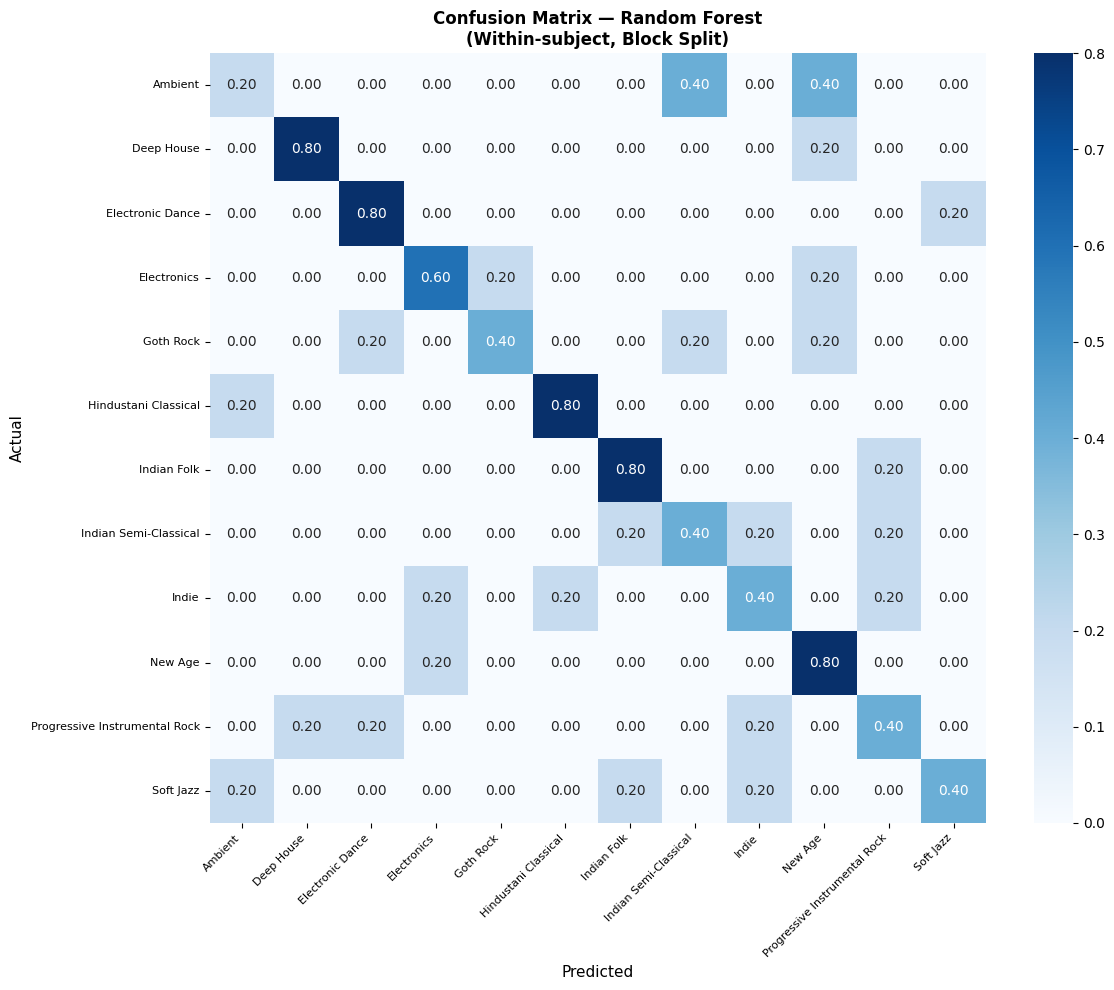

In [77]:
## Confusion matrix for best model

best_idx  = np.argmax([svm_acc, rf_acc, xgb_acc])
best_name = ['SVM', 'Random Forest', 'XGBoost'][best_idx]
best_true, best_pred = [(svm_true,svm_pred),(rf_true,rf_pred),(xgb_true,xgb_pred)][best_idx]

print(f'Best model: {best_name}')
print()
print(classification_report(best_true, best_pred, target_names=le.classes_))

cm_norm = confusion_matrix(best_true, best_pred).astype(float)
cm_norm = cm_norm / cm_norm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title(f'Confusion Matrix — {best_name}\n(Within-subject, Block Split)', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / '04_confusion_matrix.png', dpi=120)
plt.show()

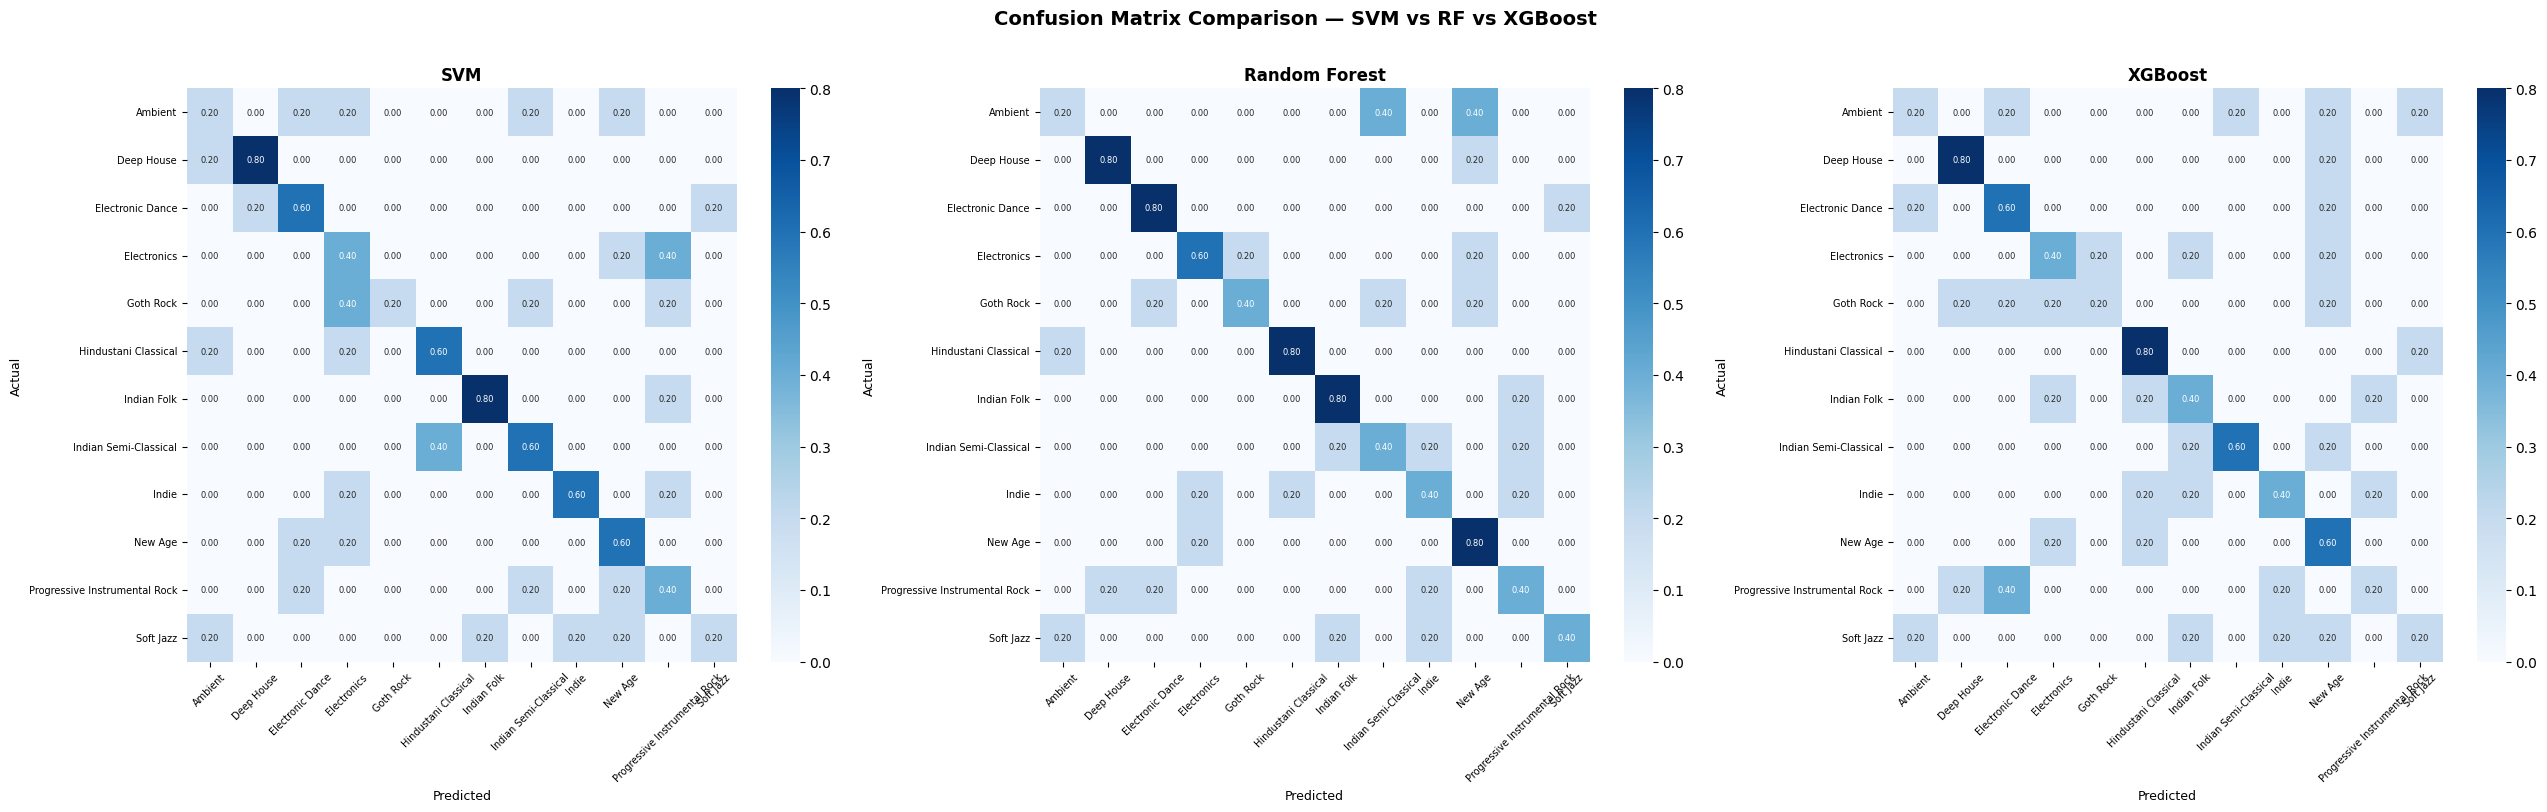

Saved: outputs/04_confusion_matrix_all.png


In [78]:
## Confusion matrix comparison for all models

fig, axes = plt.subplots(1, 3, figsize=(26, 8))
all_results = [
    ('SVM',           svm_true,  svm_pred),
    ('Random Forest', rf_true,   rf_pred),
    ('XGBoost',       xgb_true,  xgb_pred),
]

for ax, (name, true, pred) in zip(axes, all_results):
    cm = confusion_matrix(true, pred).astype(float)
    cm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_, ax=ax,
                annot_kws={'size': 6})
    ax.set_title(f'{name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Confusion Matrix Comparison — SVM vs RF vs XGBoost',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / '04_confusion_matrix_all.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/04_confusion_matrix_all.png')

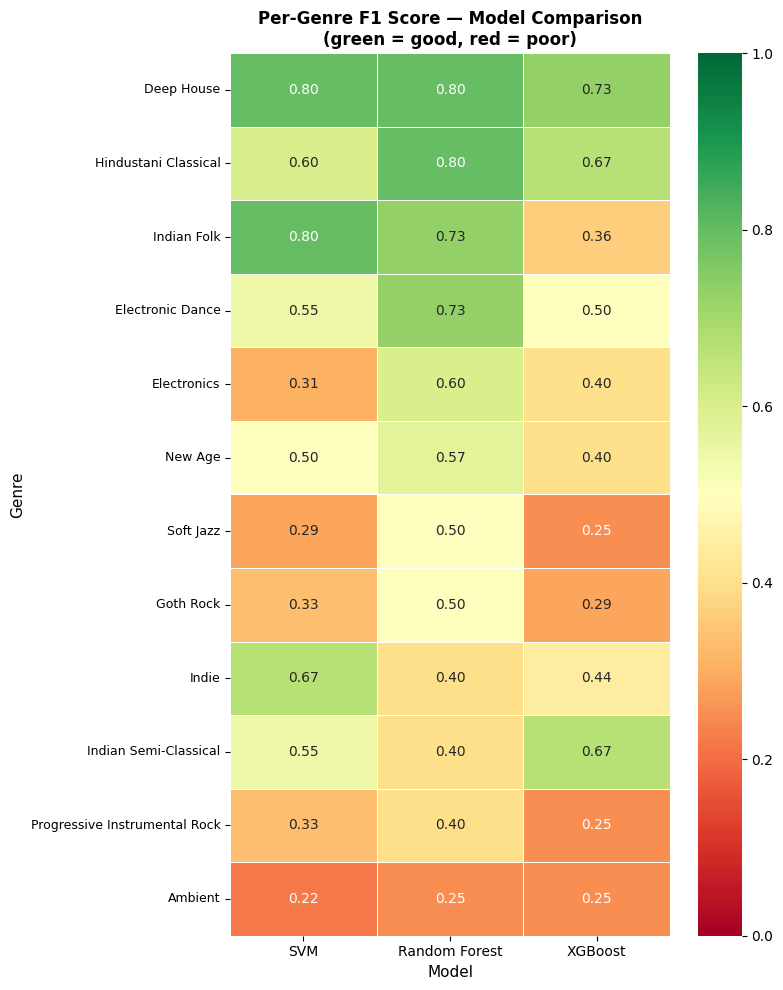

Saved: outputs/04_genre_f1_heatmap.png

Best genre per model:
  SVM             → Deep House (0.80)
  Random Forest   → Deep House (0.80)
  XGBoost         → Deep House (0.73)

Hardest genre (avg F1 across models):
  Ambient (0.24)


In [79]:
# Per-genre F1 for each model

genre_f1 = {}
for name, true, pred in [('SVM',           svm_true, svm_pred),
                          ('Random Forest', rf_true,  rf_pred),
                          ('XGBoost',       xgb_true, xgb_pred)]:
    genre_f1[name] = f1_score(true, pred, average=None)


heatmap_df = pd.DataFrame(genre_f1, index=le.classes_)

# Sort by Random Forest F1 (best model first)
heatmap_df = heatmap_df.sort_values('Random Forest', ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Per-Genre F1 Score — Model Comparison\n'
             '(green = good, red = poor)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Genre', fontsize=11)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / '04_genre_f1_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/04_genre_f1_heatmap.png')


print('\nBest genre per model:')
for col in heatmap_df.columns:
    best = heatmap_df[col].idxmax()
    print(f'  {col:<15} → {best} ({heatmap_df[col].max():.2f})')
print('\nHardest genre (avg F1 across models):')
heatmap_df['avg'] = heatmap_df.mean(axis=1)
print(f'  {heatmap_df["avg"].idxmin()} ({heatmap_df["avg"].min():.2f})')

In [87]:
## SHAP analysis for best model 

all_train_rows = []
for sub in sorted(df['subject'].unique()):
    sub_df = df[df['subject'] == sub]
    for ses in sorted(sub_df['session'].unique()):
        ses_rows = sub_df[sub_df['session'] == ses].index.tolist()
        n_test = max(1, int(len(ses_rows) * 0.3))
        all_train_rows.extend(ses_rows[:-n_test])
 
X_shap_train = df.loc[all_train_rows, feat_cols].values
y_shap_train = df.loc[all_train_rows, 'y'].values
 
n_components_shap = min(40, X_shap_train.shape[0] - 1, X_shap_train.shape[1])
 
shap_pipe = build_pipeline(
    RandomForestClassifier(
        n_estimators=500, random_state=42, n_jobs=-1
    ),
    n_components=n_components_shap
)

shap_pipe.fit(X_shap_train, y_shap_train)
print(f'SHAP model: Random Forest (best model)')
print(f'Train examples: {X_shap_train.shape[0]}')
 
X_transformed = shap_pipe[:-1].transform(X_shap_train)
pca_step      = shap_pipe.named_steps['pca']


SHAP model: Random Forest (best model)
Train examples: 300


feat_cols length      : 645
feature_importance len: 645
pca components shape  : (40, 645)
mean_shap_pca shape   : (40,)


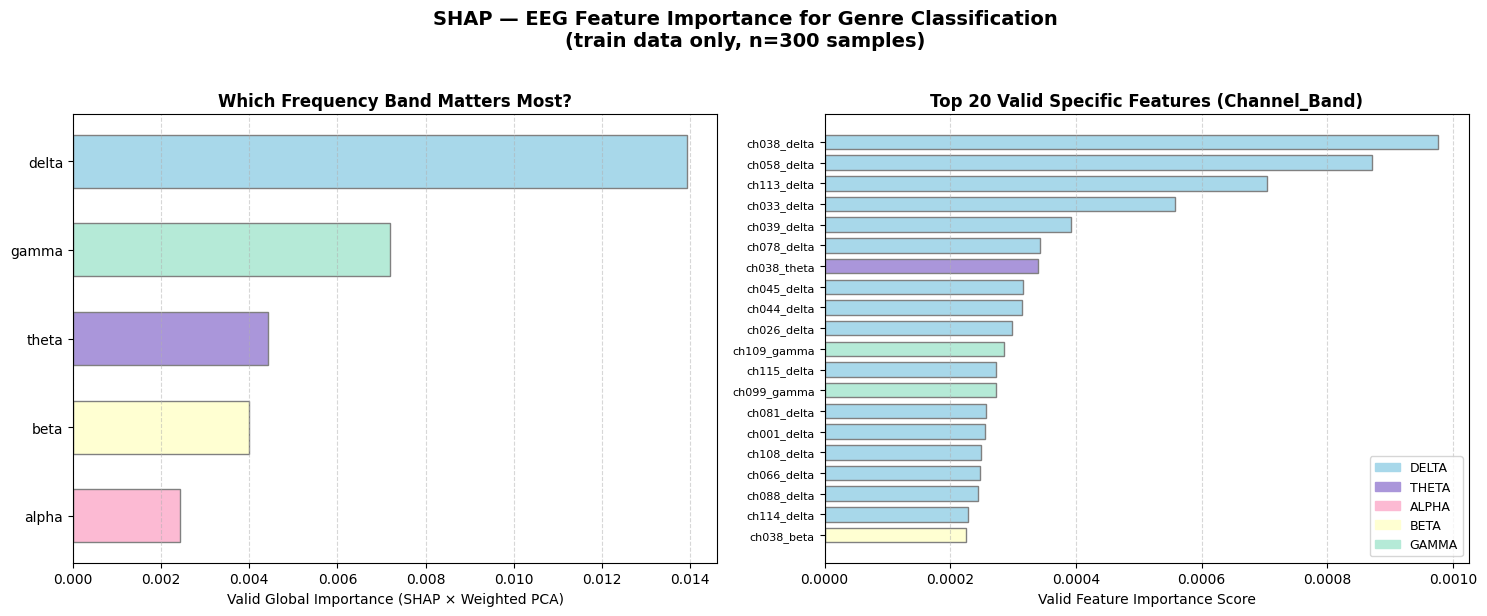

In [88]:
## SHAP ctd
raw_rf_model = shap_pipe.named_steps['model']
explainer    = shap.TreeExplainer(raw_rf_model)
shap_values  = explainer.shap_values(X_transformed)

sv = np.abs(shap_values) if not isinstance(shap_values, list) \
     else np.abs(np.array(shap_values))

if sv.ndim == 3:
    mean_shap_pca = sv.mean(axis=(0, 2))   
    if mean_shap_pca.shape[0] != 40:       
        mean_shap_pca = sv.mean(axis=(0, 1))
else:
    mean_shap_pca = sv.mean(axis=0)

evr = pca_step.explained_variance_ratio_


weighted_components = (pca_step.components_.T ** 2) * evr
feature_importance = np.sqrt(weighted_components @ (mean_shap_pca ** 2)).ravel()

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
band_colors = {
    'delta':'#a8d8ea', 'theta':'#aa96da', 'alpha':'#fcbad3',
    'beta':'#ffffd2',  'gamma':'#b5ead7'
}

band_importance = {}
for b in bands:
    idx_list = [i for i, col_name in enumerate(feat_cols) if col_name.lower().endswith(b)]
    band_importance[b] = feature_importance[idx_list].sum()


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

band_df = pd.Series(band_importance).sort_values()
axes[0].barh(band_df.index, band_df.values,
             color=[band_colors[b] for b in band_df.index], edgecolor='gray', height=0.6)
axes[0].set_xlabel('Valid Global Importance (SHAP × Weighted PCA)', fontsize=10)
axes[0].set_title('Which Frequency Band Matters Most?', fontweight='bold', fontsize=12)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)


top20_idx  = np.argsort(feature_importance.ravel())[::-1][:20]
top20_feat = [feat_cols[i] for i in top20_idx if i < len(feat_cols)]
top20_val  = feature_importance[top20_idx]         
top20_col  = [band_colors.get(f.split('_')[-1], '#ccc') for f in top20_feat]


print(f'feat_cols length      : {len(feat_cols)}')
print(f'feature_importance len: {len(feature_importance.ravel())}')
print(f'pca components shape  : {pca_step.components_.shape}')
print(f'mean_shap_pca shape   : {mean_shap_pca.shape}')

axes[1].barh(top20_feat[::-1], top20_val[::-1], color=top20_col[::-1], edgecolor='gray', height=0.7)
axes[1].set_xlabel('Valid Feature Importance Score', fontsize=10)
axes[1].set_title('Top 20 Valid Specific Features (Channel_Band)', fontweight='bold', fontsize=12)
axes[1].tick_params(axis='y', labelsize=8)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)


patches = [mpatches.Patch(color=band_colors[b], label=b.upper()) for b in bands]
axes[1].legend(handles=patches, fontsize=9, loc='lower right')

plt.suptitle('SHAP — EEG Feature Importance for Genre Classification\n(train data only, n={} samples)'.format(X_shap_train.shape[0]),     
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / '04_shap_importance.png', dpi=150, bbox_inches='tight')


plt.show()


In [89]:
## Final summary and conclusions

print('=' * 55)
print('RESULTS SUMMARY')
print('=' * 55)
print(f'Total windows   : {len(df)}')
print(f'Baseline        : {baseline*100:.1f}%  (random, 12 classes)')
print()
for _, r in results.iterrows():
    lift = r['Accuracy'] / baseline
    print(f"{r['Model']:<15} Acc: {r['Accuracy']*100:.1f}%   "
          f"F1: {r['F1 Macro']*100:.1f}%   "
          f"({lift:.1f}x above baseline)")
print()
print(f'Most important band : {band_df.index[-1].upper()}')
print(f'Best model          : {best_name}')
print()
print('Conclusion:')
print('  Accuracy above 8.3% baseline confirms that EEG signals')
print('  differ across music genres.')
print('  The models detected distinguishable EEG responses associated with different music genres.')
print('=' * 55)

RESULTS SUMMARY
Total windows   : 360
Baseline        : 8.3%  (random, 12 classes)

SVM             Acc: 50.0%   F1: 49.5%   (6.0x above baseline)
Random Forest   Acc: 56.7%   F1: 55.6%   (6.8x above baseline)
XGBoost         Acc: 45.0%   F1: 43.4%   (5.4x above baseline)

Most important band : DELTA
Best model          : Random Forest

Conclusion:
  Accuracy above 8.3% baseline confirms that EEG signals
  differ across music genres.
  The models detected distinguishable EEG responses associated with different music genres.
